In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [4]:
df = pd.read_csv('heart.csv')

In [5]:
categorical_data =df.select_dtypes(include='object')
pd.get_dummies(categorical_data)
df = pd.concat([df,pd.get_dummies(categorical_data)],axis=1)
df

C:\Users\cocoh\AppData\Local\Temp\ipykernel_10940\2939392443.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data =df.select_dtypes(include='object')


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,M,ATA,140,289,0,Normal,172,N,0.0,...,False,False,False,True,False,True,False,False,False,True
1,49,F,NAP,160,180,0,Normal,156,N,1.0,...,True,False,False,True,False,True,False,False,True,False
2,37,M,ATA,130,283,0,ST,98,N,0.0,...,False,False,False,False,True,True,False,False,False,True
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,...,False,False,False,True,False,False,True,False,True,False
4,54,M,NAP,150,195,0,Normal,122,N,0.0,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,...,False,True,False,True,False,True,False,False,True,False
914,68,M,ASY,144,193,1,Normal,141,N,3.4,...,False,False,False,True,False,True,False,False,True,False
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,...,False,False,False,True,False,False,True,False,True,False
916,57,F,ATA,130,236,0,LVH,174,N,0.0,...,False,False,True,False,False,True,False,False,True,False


In [6]:
df = pd.get_dummies(df, dtype=int)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,True,False,False,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,False,True,False,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,True,False,True,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,False,True,False,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,...,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3.4,1,False,True,True,...,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,False,True,True,...,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0.0,1,True,False,False,...,0,0,1,0,0,1,0,0,1,0


In [7]:
# Calculate the median from the NON-ZERO values
non_zero_bp = df[df['RestingBP'] > 0]['RestingBP']
bp_median = non_zero_bp.median()
print(f"Median RestingBP (non-zero values): {bp_median}") 

# Replace 0s with the calculated median
df['RestingBP'] = df['RestingBP'].replace(0, bp_median)

# Verify the fix- Check for zeros and new statistics
print(f"Number of zeros in RestingBP after replacement: {(df['RestingBP'] == 0).sum()}")
print("\nNew Summary Statistics for RestingBP:")
print(df['RestingBP'].describe())

Median RestingBP (non-zero values): 130.0
Number of zeros in RestingBP after replacement: 0

New Summary Statistics for RestingBP:
count    918.000000
mean     132.538126
std       17.990127
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


In [8]:
df.drop(df[df['RestingBP'] == 0].index, inplace=True)

In [9]:
# Calculate the median from the NON-ZERO values
non_zero_chl = df[df['Cholesterol'] > 0]['Cholesterol']
chl_median = non_zero_chl.median()
print(f"Median Cholesterol (non-zero values): {chl_median}") 

# Replace 0s with the calculated median
df['Cholesterol'] = df['Cholesterol'].replace(0, chl_median)

# Verify the fix- Check for zeros and new statistics
print(f"Number of zeros in Cholesterol after replacement: {(df['Cholesterol'] == 0).sum()}")
print("\nNew Summary Statistics for Cholesterol:")
print(df['Cholesterol'].describe())

Median Cholesterol (non-zero values): 237.0
Number of zeros in Cholesterol after replacement: 0

New Summary Statistics for Cholesterol:
count    918.000000
mean     243.204793
std       53.401297
min       85.000000
25%      214.000000
50%      237.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64


In [10]:
X = df.drop(columns = 'HeartDisease')
y = df['HeartDisease']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
duplicate_columns = X_train.columns[X_train.columns.duplicated(keep=False)]

print(duplicate_columns.value_counts())


Sex_F                2
Sex_M                2
ChestPainType_ASY    2
ChestPainType_ATA    2
ChestPainType_NAP    2
ChestPainType_TA     2
RestingECG_LVH       2
RestingECG_Normal    2
RestingECG_ST        2
ExerciseAngina_N     2
ExerciseAngina_Y     2
ST_Slope_Down        2
ST_Slope_Flat        2
ST_Slope_Up          2
Name: count, dtype: int64


In [14]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Duplicate columns:")
print(X_train.columns[X_train.columns.duplicated()])


X_train shape: (734, 20)
X_test shape: (184, 20)
Duplicate columns:
Index([], dtype='str')


In [16]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
print("Best parameters:")
print(lr_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(lr_grid.best_score_)

best_lr = lr_grid.best_estimator_


Best parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}

Best CV ROC-AUC:
0.922742553040656


In [17]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV ROC-AUC:
0.9331182999475682


In [18]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_params = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best parameters:")
print(svm_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(svm_grid.best_score_)

best_svm = svm_grid.best_estimator_



Best parameters:
{'model__C': 0.1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Best CV ROC-AUC:
0.9224886485591093


c:\Users\cocoh\Downloads\heart_failure_prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [19]:
print("Logistic Regression:", lr_grid.best_score_)
print("Random Forest:", rf_grid.best_score_)
print("SVM:", svm_grid.best_score_)


Logistic Regression: 0.922742553040656
Random Forest: 0.9331182999475682
SVM: 0.9224886485591093


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8858695652173914
Precision: 0.8785046728971962
Recall: 0.9215686274509803
F1 Score: 0.8995215311004785
ROC-AUC: 0.933405069344811

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        82
           1       0.88      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


Confusion Matrix:
[[69 13]
 [ 8 94]]


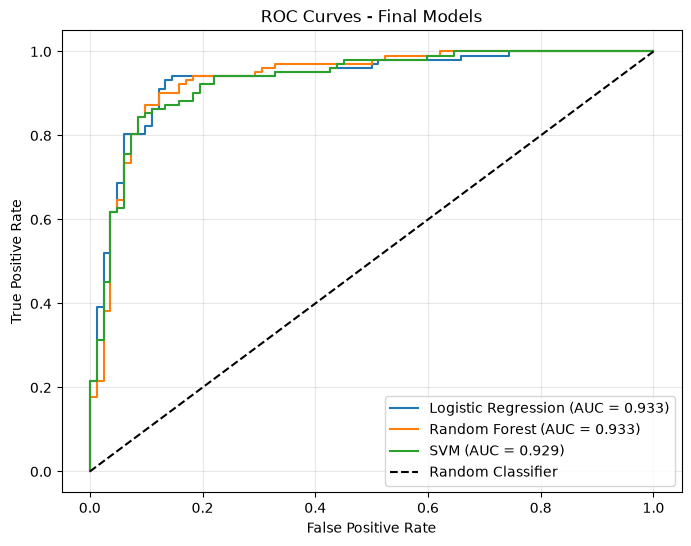

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "SVM": best_svm
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Final Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "SVM": best_svm
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



Logistic Regression
Accuracy: 0.8967391304347826
Precision: 0.8952380952380953
Recall: 0.9215686274509803
F1 Score: 0.9082125603864735
ROC-AUC: 0.9332855093256814

Confusion Matrix:
[[71 11]
 [ 8 94]]

Random Forest
Accuracy: 0.8858695652173914
Precision: 0.8785046728971962
Recall: 0.9215686274509803
F1 Score: 0.8995215311004785
ROC-AUC: 0.933405069344811

Confusion Matrix:
[[69 13]
 [ 8 94]]

SVM
Accuracy: 0.8641304347826086
Precision: 0.8598130841121495
Recall: 0.9019607843137255
F1 Score: 0.8803827751196173
ROC-AUC: 0.929220468675275

Confusion Matrix:
[[67 15]
 [10 92]]
